## Bluesky


##### Useful links:

- [Bluesky Docs](https://docs.bsky.app/)
- [Bluesky SDK](https://docs.bsky.app/docs/get-started)
- [Bluesky API Python Client](https://atproto.blue/en/latest/)


In [ ]:
# Requirements
%pip install pandas python-dotenv atproto

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
import json
import os
import time
from datetime import datetime, timezone
from typing import Any

import pandas as pd
from atproto import Client
from atproto_client.models.app.bsky.feed.search_posts import Params
from dateutil.relativedelta import relativedelta
from dotenv import load_dotenv

pd.set_option("display.max_rows", 500)
pd.set_option("display.max_columns", 500)
pd.set_option("display.width", 1000)

DATA_DIR = "../../data"
BASE_NAME = "br-bluesky-UGC"


def save_json(question_info: str, json_data: list[Any] | dict[str, Any]):
    now_str = datetime.now(tz=timezone.utc).isoformat()
    filepath = f"{DATA_DIR}/{BASE_NAME}-{question_info}-{now_str}.json"
    print(filepath)
    with open(filepath, "w") as fout:
        json.dump(json_data, fout, indent=4, ensure_ascii=False)

In [3]:
# Environment variables
load_dotenv()
BLUESKY_HANDLE = os.getenv("BLUESKY_HANDLE")
BLUESKY_PASSWORD = os.getenv("BLUESKY_PASSWORD")

In [4]:
# API connection
CLIENT = Client()
profile = CLIENT.login(BLUESKY_HANDLE, BLUESKY_PASSWORD)

### SPECIAL CRITERIA


##### **SC1: Does the platform offer an API for collecting public user-generated content data?**

_This item verifies whether the platform provides an API with at least one endpoint for programmatically extracting public user-generated content to the users’ infrastructure. Public user-generated content is defined here as any publicly visible publication accessible by any platform user. The assessment should verify that the endpoint allows retrieval and storage of this content without requiring privileged or internal access beyond standard developer registration._


In [ ]:
question1 = "question-01-data"
# Requesting all the current posts from a specific page's feed:
response = CLIENT.get_author_feed(actor="forbes.com")
# Saving and showing author, text and creation timestamp for the first 10 posts:
posts = [vp.post.model_dump() for vp in response.feed[:10]]
save_json(question1, posts)
pd.json_normalize(posts)[["author.handle", "record.text", "record.created_at"]]

../../data/br_bluesky-UGC-question-01-data-2025-10-28T23:51:18.374981+00:00.json


,author.handle,record.text,record.created_at
0,zacheverson.com,"Watch: ""White House Demolition Isn’t Trump's F...",2025-10-28T20:21:25.809Z
1,forbes.com,The lawsuit accuses Stake of disguising itself...,2025-10-28T20:20:07Z
2,forbes.com,The curved viewing line for Tuesday’s northern...,2025-10-28T20:10:02Z
3,thealexknapp.bsky.social,Filling in for @thomasbrewster.bsky.social on ...,2025-10-28T19:48:13.129Z
4,pheebini.bsky.social,Thanks to his $130 million donation to pay tro...,2025-10-28T19:31:52.340Z
5,forbes.com,Tesla’s stock has risen in recent days as trad...,2025-10-28T18:50:05Z
6,forbes.com,Microsoft will have a roughly 27% stake in the...,2025-10-28T18:05:04Z
7,forbes.com,"Allen released “West End Girl” on Friday, in w...",2025-10-28T16:55:03Z
8,forbes.com,The Department of Agriculture has said benefit...,2025-10-28T16:50:04Z
9,forbes.com,The iPhone maker’s stock has surged in recent ...,2025-10-28T15:45:08Z


### ACCESSIBILITY


##### **OC1: Does the platform offer any type of access to non-public data (e.g., private groups, not direct messages) to approved researchers?**

_This item verifies whether, beyond the retrieval and extraction of public user-generated content data, the API permits the extraction of any data from non-public content, such as posts and comments in private groups or discussion forums, subject to the implementation of adequate data hashing measures and specific researcher approval. The assessment should confirm that the API provides such access measures, either through specific endpoints or other controlled access mechanisms._


We defend that this question is not applicable for Bluesky, because:

- There is no specific authentication for researchers.
- There is no private accounts or posts at Bluesky
- There are no private groups or discussion forums at Bluesky.
- There are only one-on-one messages on the platform and messages from the user can be retrieved using API


##### **OC2: Can the requested data be extracted directly from the platform’s API response?**

_This item verifies whether the API returns structured data directly in its response, rather than only providing a redirect link to the data. Audiovisual media (e.g., images, videos, and audio) are excluded from this assessment. The assessment should check sample API responses to confirm that the requested public data is included in the returned payload itself._


In [ ]:
question2 = 'question-02-data'
# Requesting all the current posts from a specific page's feed:
response = CLIENT.get_author_feed(actor="forbes.com")
# Showing all the data from the first post retrieved:
data = response.feed[0].post.model_dump()
save_json(question2, data)
pd.json_normalize(data).T

../../data/br_bluesky-UGC-question-02-data-2025-10-28T23:51:19.212980+00:00.json


,0
cid,bafyreidsxpvjhjekrdwt2cwwbvnv5lsrqipfi4iyl5wev...
indexed_at,2025-10-28T20:21:26.458Z
uri,at://did:plc:moye3apncjjbyqgb7orp5quj/app.bsky...
labels,[]
like_count,29
quote_count,0
reply_count,1
repost_count,6
threadgate,None
py_type,app.bsky.feed.defs#postView


##### **OC4: Does the platform’s API offer an endpoint for extracting data from an individual publication?**

_This item verifies whether it is possible to collect data from a specific public post on the platform using a unique identifier, rather than relying on search terms or other filters. The assessment should review the API documentation and test available endpoints to confirm that an individual publication can be retrieved directly by its unique identifier._


In [ ]:
question4 = "question-04-data"
# Requesting a specific post from a post_id.
# The id is present at the end of the post URL:
# https://bsky.app/profile/forbes.com/post/3m3fq5cobpe2g
post_id = "3m3fq5cobpe2g"
author_handle = "forbes.com"
post = CLIENT.get_post(post_rkey=post_id, profile_identify=author_handle)
post_data = post.model_dump()
save_json(question4, post_data)
pd.json_normalize(post_data).T

../../data/br_bluesky-UGC-question-04-data-2025-10-28T23:51:19.628941+00:00.json


,0
uri,at://did:plc:2w45zyhuklwihpdc7oj3mi63/app.bsky...
cid,bafyreiegsinncqnrctb2sdtbfp5y4m7nmbvukod6x7ugj...
value.created_at,2025-10-17T16:50:04Z
value.text,Bolton appeared in court Friday after being in...
value.embed.external.description,Bolton appeared in court Friday after being in...
value.embed.external.title,John Bolton Pleads Not Guilty—Here’s Why His C...
value.embed.external.uri,http://www.forbes.com/sites/alisondurkee/2025/...
value.embed.external.thumb.mime_type,image/jpeg
value.embed.external.thumb.size,63135
value.embed.external.thumb.ref.link,bafkreia555fuxrvslemnjna3ecvyxnous35gs3ixlbkho...


##### **OC5: Does the platform’s API offer an endpoint for extracting data from an individual author?**

_This item verifies whether it is possible to collect data from public posts made by a specific author, using their username or unique identifier. The assessment should review the API documentation and test relevant endpoints to confirm that data can be retrieved directly for an individual author._


In [ ]:
question5 = "question-05-data"
author = CLIENT.get_profile("forbes.com")
author_data = author.model_dump()
save_json(question5, author_data)
pd.json_normalize(author_data).T

../../data/br_bluesky-UGC-question-05-data-2025-10-28T23:51:20.132671+00:00.json


,0
did,did:plc:2w45zyhuklwihpdc7oj3mi63
handle,forbes.com
avatar,https://cdn.bsky.app/img/avatar/plain/did:plc:...
banner,https://cdn.bsky.app/img/banner/plain/did:plc:...
created_at,2023-04-27T20:35:48.951Z
description,None
display_name,Forbes
followers_count,61341
follows_count,42
indexed_at,2025-08-05T14:01:37.698Z


##### **OC6: Does the platform’s API provide an endpoint for extracting data based on search terms?**

_This item verifies whether public user-generated content can be collected via individual or combined search terms, enabling the creation of datasets of posts mentioning those terms. The assessment should test search-related endpoints to confirm that queries using keywords return relevant public posts._


In [ ]:
question6 = "question-06-data"
# Requesting all the current posts with a specific search term:
search_term = "Climate Change"
response = CLIENT.app.bsky.feed.search_posts({"q": search_term})
posts = response.model_dump()["posts"][:10]
save_json(question6, posts)
pd.json_normalize(posts)[["author.handle", "record.text", "record.created_at"]]

../../data/br_bluesky-UGC-question-06-data-2025-10-28T23:51:20.766177+00:00.json


,author.handle,record.text,record.created_at
0,vero1986.bsky.social,The climate change deniers will have to count ...,2025-10-28T23:50:56.768Z
1,climateactapp.bsky.social,"Fueled by warming oceans, #HurricaneMelissa is...",2025-10-28T23:49:08.823Z
2,unauthorizedbeast.bsky.social,Climate change is real. And devastating.,2025-10-28T23:49:04.157Z
3,cmgiulini.bsky.social,That war against climate change? We lost. The ...,2025-10-28T23:48:54.745Z
4,petergarbutt.bsky.social,Climate change says Bill Gates will lead to hu...,2025-10-28T23:48:12.096Z
5,litzz11.bsky.social,And I don’t care what Bill Gates says. Climate...,2025-10-28T23:48:02.268Z
6,reggieisdead.bsky.social,Me and my libido demon on a random Tuesday at ...,2025-10-28T23:47:02.669Z
7,keith65.bsky.social,“With the [prevention plan] and climate change...,2025-10-28T23:46:12.034Z
8,stevensaus.faithcollapsing.com.ap.brid.gy,"[uspol,climate]\n\n(22 Oct) New Report Finds E...",2025-10-28T23:46:12.000Z
9,roughrider994.bsky.social,HELL FREEZES OVER: Noted Billionaire Climate A...,2025-10-28T23:46:08.004Z


##### **OC7: Does the API use locale-neutral data representations?**

_This item verifies whether locale-sensitive data (e.g., timestamps, currency, numbers) are returned in a locale-neutral format, or whether relevant locale metadata is included when neutrality is not possible. The assessment should review the API documentation and inspect sample responses to confirm the presence of standardized formats or accompanying metadata._


In [130]:
# The only type of data that fits the description is the timestamp,
# which comes in isoformat with milliseconds and standardized to UTC.
# Example:
profile.created_at

'2025-10-14T20:11:50.713Z'

### COMPLIANCE


##### **OC15: Does the platform provide a way to label content that has been generated with artificial intelligence?**

_This item verifies whether the platform automatically flags, or allows users to flag, AI-generated content, and whether this information is given in the API response. The assessment should review the documentation and test API outputs to confirm that these flags are included in the extracted data._


The Bluesky API only provides a way to a post author self-label the post content.

- Check [SelfLabel definition](https://atproto.blue/en/latest/atproto/atproto_client.models.com.atproto.label.defs.html#atproto_client.models.com.atproto.label.defs.SelfLabel).


### COMPLETENESS


##### **OC16: Can data from a publication’s comments be extracted using the platform’s API?**

_This item verifies whether comment data, including their content, can be extracted when available on the platform, either together with publication data or with a dedicated endpoint. The assessment should test relevant endpoints to confirm that comments are retrievable as structured data. This item does not apply to platforms that do not have commenting features._


In [ ]:
question16 = "question-16-data"
# Showing the first 10 replies to the same post retrieved at questions OC4:
post_id = "3m3fq5cobpe2g"
author_handle = "forbes.com"
post_record = CLIENT.get_post(post_rkey=post_id, profile_identify=author_handle)
post_thread = CLIENT.get_post_thread(post_record.uri)
replies = post_thread.thread.model_dump()["replies"][:10]
save_json(question16, replies)
pd.json_normalize(replies)[
    ["post.author.handle", "post.record.text", "post.record.created_at"]
]

../../data/br_bluesky-UGC-question-16-data-2025-10-28T23:51:21.667281+00:00.json


,post.author.handle,post.record.text,post.record.created_at
0,byteintime.bsky.social,"This is great, they are eating their own. \n\n...",2025-10-18T18:43:53.773Z
1,jpjh88.bsky.social,But they aren't much different than the invest...,2025-10-18T04:00:18.656Z
2,wymanv.bsky.social,Looking forward to the evidence this regime pr...,2025-10-18T21:24:52.980Z
3,lloydbeatz.bsky.social,Well he WAS part of the Trump administration. ...,2025-10-18T19:05:23.438Z
4,kengriff.bsky.social,Let’s goooo,2025-10-18T15:21:33.958Z
5,thomaswolfe.bsky.social,Bc they are 1% as bad as what trump should hav...,2025-10-18T22:03:32.631Z
6,bikerwitch1.bsky.social,You almost want to feel bad for the guy. Almost.,2025-10-17T17:16:23.606Z
7,anonperson8479.bsky.social,Bolton is a difficult persona: He wasn't intr...,2025-10-18T02:43:29.504Z
8,proofneeded.bsky.social,Just another spite case with no merit than to ...,2025-10-18T13:35:48.036Z
9,button628.bsky.social,Just think if he'd only have done the right th...,2025-10-18T15:35:29.325Z


##### **OC17: Can data from temporary content be extracted through the platform’s API?**

_This item verifies whether the platform’s API provides at least one endpoint for collecting data from temporary publications (e.g., stories, ephemeral messages). The assessment should test endpoints to confirm whether this type of short-lived content can be retrieved as structured data before it expires. This item does not apply to platforms that do not have temporary content features._


Not applicable:

- Bluesky does not have temporary content features.


##### **OC18: Can historical data be extracted through the platform’s API?**

_This item verifies whether the API provides endpoints that allow for a specified time range, going back more than one year from the time the request is made, to collect public user-generated content data. The assessment should review test endpoints to confirm that historical data more than 12 months prior to the analysis can be retrieved._


In [ ]:
question18 = "question-18-data"
# Showing first 10 posts from dates until two years ago:
two_years_ago = datetime.now(tz=timezone.utc) - relativedelta(years=2)
response = CLIENT.app.bsky.feed.search_posts(
    {"q": "Climate Change", "until": two_years_ago.isoformat()}
)
posts = response.model_dump()["posts"][:10]
save_json(question18, posts)
pd.json_normalize(posts)[["author.handle", "record.text", "record.created_at"]]

../../data/br_bluesky-UGC-question-18-data-2025-10-28T23:51:22.236020+00:00.json


,author.handle,record.text,record.created_at
0,punkymaysnark.bsky.social,"""What do nipples have to do with climate chang...",2023-10-28T23:38:43.829Z
1,srmullens.bsky.social,"More and more, I’m seeing info that the world ...",2023-10-28T23:36:39.619Z
2,bigfatbartolocolon.bsky.social,the worst part is this country is so dumb this...,2023-10-28T23:34:11.970Z
3,trend-words-en.bsky.social,[LongRun] nipple bra in honor of climate change,2023-10-28T23:31:55.911291600Z
4,mech0t1.bsky.social,Nips out for climate change,2023-10-28T23:29:12.473Z
5,feijoasforever.bsky.social,Move over Greta there’s another icon of climat...,2023-10-28T23:27:41.022Z
6,teawhilewriting.bsky.social,Welp now we’re all talking about nipple bras i...,2023-10-28T23:25:50.168Z
7,coralgartner.bsky.social,Another horror fire season has already started...,2023-10-28T23:25:12.365Z
8,phoebebarton.bsky.social,it would've been a lot easier to address clima...,2023-10-28T23:10:11.140Z
9,davidho.bsky.social,Reactions to story about pigeons and AI:\n\nMa...,2023-10-28T23:09:37.595Z


##### **OC19: Is the number of requests allowed by the API sufficient for monitoring more than 10,000 publications in 24 hours?**

_This item verifies whether data can be extracted without interruption and losses through the platform’s API for requests that accumulate more than 10,000 publications in 24 hours. The assessment should test the API to confirm that this volume of data can be collected continuously._


Yes. During our tests, we were able to obtain more than 10,000 publications in less than 10 minutes.

In [4]:
stats_filename = (
    "br-bluesky-UGC-question-19-stats-2025-11-27T02-59-34-052781.json"
)
with open(f"{DATA_DIR}/{stats_filename}", "r") as fin:
    stats = json.load(fin)
pd.json_normalize(stats).set_index(pd.Index(["stats"])).T

,stats
start_time,2025-11-27T02:59:34.052781+00:00
end_time,2025-11-27T03:07:18.295157+00:00
queries,"[Climate, Engineering]"
total_acquision_time_hour,0.13
total_requests_made,106
total_data_collected,10514


### CONSISTENCY


##### **OC20: Are the results returned by the API consistently reproducible?**

_This item verifies whether data extracted via the platform’s API at any given time is consistent with other collections performed similarly, including content that has been deleted between collections. The assessment should conduct repeated test queries to confirm the reproducibility of results or ground the response based on recent (less than 2 years) experiments published in peer-reviewed journals._


Test instructions: Please, develop a test that collects data for 5 times using the same request parameters and the same endpoint. Save each response in separate files.


Yes. The same request was made five times with a sleep of 3 minutes between requests and the same results were retrieved.

In [ ]:
question20 = "question-20-run"
total_runs = 5
limit_dt = datetime.now(timezone.utc).isoformat()
for index in range(1, total_runs + 1):
    response = CLIENT.app.bsky.feed.search_posts(
        {"q": "Climate Change", "until": limit_dt}
    )
    save_json(f"{question20}-{index}", response.model_dump())
    time.sleep(60 * 3)  # Sleeping for 3 minute

In [ ]:
# Showing that the 5 responses share the same posts:
results = []
filenames = []
for filename in os.listdir(DATA_DIR):
    if "bluesky" in filename and question20 in filename:
        filenames.append(filename)
for filepath in [f"{DATA_DIR}/{filename}" for filename in sorted(filenames)]:
    if os.path.isfile(filepath):
        print(filepath)
        with open(filepath) as fin:
            results.append(json.load(fin))
all_cids = []
for result in results:
    all_cids.append(set([post["cid"] for post in result["posts"]]))
print("1 and 2 are equal:", all_cids[0] == all_cids[1])
print("2 and 3 are equal:", all_cids[1] == all_cids[2])
print("3 and 4 are equal:", all_cids[2] == all_cids[3])
print("4 and 5 are equal:", all_cids[3] == all_cids[4])

../../data/br-bluesky-UGC-question-20-run-1-2025-11-28T15:29:21.551730+00:00.json
../../data/br-bluesky-UGC-question-20-run-2-2025-11-28T15:32:22.809960+00:00.json
../../data/br-bluesky-UGC-question-20-run-3-2025-11-28T15:35:23.911410+00:00.json
../../data/br-bluesky-UGC-question-20-run-4-2025-11-28T15:38:24.953288+00:00.json
../../data/br-bluesky-UGC-question-20-run-5-2025-11-28T15:41:26.239978+00:00.json
1 and 2 are equal: True
2 and 3 are equal: True
3 and 4 are equal: True
4 and 5 are equal: True


##### **OC21: Is the data returned by the platform’s API consistent with the parameters and filters used in the request?**

_This item verifies whether the data extracted through the API accurately reflects the parameters and filters specified in the request. The assessment should conduct repeated test queries to confirm the consistency of results or ground the response based on recent (less than 2 years) experiments published in peer-reviewed journals._


Test instructions: Please, develop a process that request data using different parameter to the same endpoint. If possible, test at least 5 different parameters/filters. If the platform provides less than 5, use all available parameters/filters.

Save each response in separate files.


In [ ]:
# First we define the tests:


def test_author(response: dict[str, Any], author: str) -> None:
    authors = set([post["author"]["handle"] for post in response["posts"]])
    outcome = "SUCCESS" if authors == {author} else "FAILURE"
    print(f"[{outcome}] Authors found: {authors}")


def test_domain(response: dict[str, Any], domain: str) -> None:
    numposts = len(response["posts"])
    failures = 0
    for index, post in enumerate(response["posts"]):
        if domain not in json.dumps(post["record"]):
            print(f">>> {domain} not found in post {index}")
            failures += 1
    outcome = "SUCCESS" if not failures else "FAILURE"
    percent = (numposts - failures) / numposts
    print(f"[{outcome}] Found domain {domain} at {percent:.1%} of posts")


def test_mentions(response: dict[str, Any], mentions: str) -> None:
    page_did = CLIENT.get_profile(mentions.lstrip("@")).did
    numposts = len(response["posts"])
    failures = 0
    for index, post in enumerate(response["posts"]):
        if page_did not in json.dumps(post["record"]):
            print(f">>> {mentions} not found in post {index}")
            failures += 1
    outcome = "SUCCESS" if not failures else "FAILURE"
    percent = (numposts - failures) / numposts
    print(f"[{outcome}] Found mentions to {mentions} at {percent:.1%} of posts")


def test_url(response: dict[str, Any], url: str) -> None:
    numposts = len(response["posts"])
    failures = 0
    for index, post in enumerate(response["posts"]):
        if url not in json.dumps(post["record"]):
            print(f">>> URL not found in post {index}")
            failures += 1
    outcome = "SUCCESS" if not failures else "FAILURE"
    percent = (numposts - failures) / numposts
    print(f"[{outcome}] URL present at {percent:.1%} of posts")


def test_until(response: dict[str, Any], until: str) -> None:
    until_dt = datetime.fromisoformat(until)
    numposts = len(response["posts"])
    failures = 0
    for index, post in enumerate(response["posts"]):
        created_at = datetime.fromisoformat(post["record"]["created_at"])
        if not (created_at <= until_dt):
            print(f">>> Post {index} created after 'until' date: {created_at}")
            failures += 1
    outcome = "SUCCESS" if not failures else "FAILURE"
    percent = (numposts - failures) / numposts
    print(f"[{outcome}] Found {percent:.1%} of posts created before {until}")


def test_response(response: dict[str, Any], param: str, value: str) -> None:
    tests = {
        "author": test_author,
        "domain": test_domain,
        "mentions": test_mentions,
        "url": test_url,
        "until": test_until,
    }
    assert param in tests, f"Test not implemented for parameter '{param}'"
    tests.get(param, lambda x, y: None)(response, value)

In [ ]:
question21 = "question-21-run"
utc_now = datetime.now(tz=timezone.utc)
yesterday = utc_now - relativedelta(days=1)
five_years_ago = utc_now - relativedelta(years=5)
url = (
    "https://yaleclimateconnections.org/2025/10/catastrophic-hurricane-melissa-"
    "hits-jamaica-as-the-strongest-landfalling-atlantic-hurricane-on-record/"
)
parameters: list[tuple[str, str | int | list[str]]] = [
    ("author", "forbes.com"),
    ("domain", "arxiv.org"),
    ("mentions", "metoffice.gov.uk"),
    ("until", five_years_ago.isoformat()),
    ("url", url),
]
for index, (param, value) in enumerate(parameters, start=1):
    time.sleep(2)
    params = Params(**{"q": "Climate", param: value})
    response = CLIENT.app.bsky.feed.search_posts(params)
    save_json(f"{question21}-{index}-{param}", response.model_dump())
    test_response(response.model_dump(), param, str(value))

../../data/br-bluesky-UGC-question-21-run-1-author-2025-11-13T13:35:23.656632+00:00.json
[SUCCESS] Authors found: {'forbes.com'}
../../data/br-bluesky-UGC-question-21-run-2-domain-2025-11-13T13:35:25.987160+00:00.json
[SUCCESS] Found domain arxiv.org at 100.0% of posts
../../data/br-bluesky-UGC-question-21-run-3-mentions-2025-11-13T13:35:28.616458+00:00.json
[SUCCESS] Found mentions to metoffice.gov.uk at 100.0% of posts
../../data/br-bluesky-UGC-question-21-run-4-until-2025-11-13T13:35:31.330232+00:00.json
[SUCCESS] Found 100.0% of posts created before 2020-11-13T13:35:20.912685+00:00
../../data/br-bluesky-UGC-question-21-run-5-url-2025-11-13T13:35:33.949470+00:00.json
[SUCCESS] URL present at 100.0% of posts


### RELEVANCE


##### **OC22: Does the data extracted by the platform’s API reflect what is displayed on its user interface?**

_This item verifies whether the data returned by the API corresponds to the information displayed on the platform’s user interface at all levels of detail. The assessment should compare API responses with the user interface to confirm that key elements—such as authorship, complete content, interaction counts (e.g., comments, shares, replies), and referenced content (e.g., shares, mentions)—are fully represented._


In [ ]:
question22 = "question-22-data"
# Requesting all the current posts with a specific search term:
search_term = "Software Engineering"
response = CLIENT.app.bsky.feed.search_posts({"q": search_term, "sort": "top"})
# Saving run:
posts_data = response.model_dump()
save_json(question22, posts_data)
# Showing the text from each of the first 3 posts:
columns_to_show = [
    "author.handle",
    "record.text",
    "record.created_at",
    "embed.record.author.handle",
    "embed.record.value.text",
]
pd.json_normalize(posts_data["posts"])[columns_to_show].head(3)

../../data/br-bluesky-UGC-question-22-data-2025-10-29T16:22:33.719008+00:00.json


,author.handle,record.text,record.created_at,embed.record.author.handle,embed.record.value.text
0,magisterjezza.bsky.social,Software engineering is the new paying people ...,2025-10-29T04:36:14.369Z,letitmelo.bsky.social,"""250x bigger and lost"" is pretty insane. Imagi..."
1,ed3d.net,if you are going to traumatize Young Devlopers...,2025-10-29T13:08:13.867Z,ed3d.net,The quality floor of new grads has also EVAPOR...
2,shimminykricket.bsky.social,"This is textbook example of reducing ""tech"" to...",2025-10-27T17:21:38.494Z,NaN,NaN


A print of the UI showing that the result is the same

(also available at `../../data/br-bluesky-UGC-question-22-screenshot.png`):

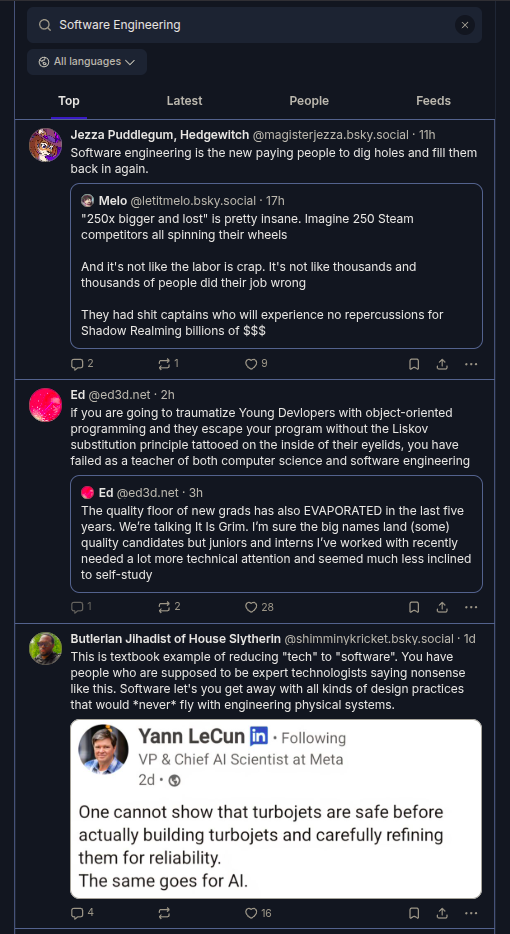

##### **OC23: Does the platform’s API allow for filtering data based on publisher location?**

_This item verifies whether the API supports applying location-based filters to data extraction. The assessment should test the endpoint for the main content type to confirm that data on public posts can be filtered by publisher location._


There is no parameter to filter by location when searching for posts in Bluesky API.

##### **OC24: Does the platform’s API allow for filtering data based on content language?**

_This item verifies whether the API allows for applying language-based filters to data extraction. The assessment should test the endpoint for the main content type to confirm that public post data can be filtered by content language._


In [ ]:
question24 = "question-24-data"
language = "pt"
response = CLIENT.app.bsky.feed.search_posts({"q": "Climate", "lang": language})
data = response.model_dump()
save_json(question24, data)
pd.json_normalize(data["posts"])[
    ["author.handle", "record.text", "record.created_at"]
].head()

../../data/br_bluesky-UGC-question-24-data-2025-10-29T02:56:22.751578+00:00.json


,author.handle,record.text,record.created_at
0,yrs-pa.bsky.social,Pontos importantes trazidos pela @analesnovski...,2025-10-29T01:31:07.037Z
1,paulo.pfmj.me,ainda sobre a mudança de postura em relação ao...,2025-10-28T23:29:36.534Z
2,spicyethicsprof.bsky.social,Now why would Starbucks announce they dropping...,2025-10-28T23:19:59.875Z
3,grandmasweb.bsky.social,Widespread immigration raids are creating a pe...,2025-10-28T17:35:57.354Z
4,cop30brazil.bsky.social,🤖 Artificial Intelligence could be a game-chan...,2025-10-28T13:14:38.894Z


##### **OC25: Does the platform’s API allow for filtering data by specific time periods?**

_This item verifies whether the API allows applying temporal filters to data extraction. The assessment should test the endpoint for the main content type to confirm that public post data can be filtered by custom time ranges._


In [ ]:
question25 = "question-25-data"
now = datetime.now(tz=timezone.utc)
initial_date = (now - relativedelta(years=5)).isoformat()
final_date = (now - relativedelta(years=3)).isoformat()
response = CLIENT.app.bsky.feed.search_posts(
    {"q": "Climate", "since": initial_date, "until": final_date}
)
data = response.model_dump()
save_json(question25, data)
pd.json_normalize(data["posts"])[
    ["author.handle", "record.text", "record.created_at"]
].head()

../../data/br_bluesky-UGC-question-25-data-2025-10-29T03:01:31.362319+00:00.json


,author.handle,record.text,record.created_at
0,doty-count.bsky.social,I didn’t think I wouldn’t see climate change i...,2022-10-29T00:43:03.000Z
1,deepseadawn.bsky.social,Very excited to give a full recap of my #Chall...,2022-10-29T00:24:56Z
2,bryony-hazelnut.bsky.social,@RishiSunak The most important thing in our li...,2022-10-28T22:49:02Z
3,mhotmessgandhi.bsky.social,Act of Refusal for Architects #39: Anti-Pledg...,2022-10-28T22:26:39Z
4,mhotmessgandhi.bsky.social,Act of Refusal for Architects #39: Anti-Pledg...,2022-10-28T22:26:39.000Z


### TIMELINESS


##### **OC26: Can data from newly published content be extracted from the platform’s API in near real time?**

_This item verifies whether the API allows the collection of data from specific content within one hour of its publication. The assessment should test the endpoint for the main content type to confirm that it allows the ready extraction of recent public posts data._


In [ ]:
question26 = "question-26-data"
collection_date = datetime.now(tz=timezone.utc)
one_hour_ago = collection_date - relativedelta(hours=1)
response = CLIENT.app.bsky.feed.search_posts(
    {"q": "Climate", "since": one_hour_ago.isoformat()}
)
posts_data = response.model_dump()
save_json(question26, posts_data)
df = pd.json_normalize(posts_data["posts"])
dt_column_name = "record.created_at"
df[dt_column_name] = pd.to_datetime(df[dt_column_name], format="mixed")
df.sort_values(dt_column_name, ascending=False, inplace=True)
most_recent_post_date = df[dt_column_name][0]
print("\nCollection date:", collection_date)
print("Most recent post:", most_recent_post_date)
display(df[["author.handle", "record.text", dt_column_name]].head())

../../data/br_bluesky-UGC-question-26-data-2025-10-29T01:57:48.080175+00:00.json

Collection date: 2025-10-29 01:57:47.162031+00:00
Most recent post: 2025-10-29 01:57:11.278000+00:00


,author.handle,record.text,record.created_at
0,magpiesaid.bsky.social,"I was born in Ghana, 'white man's grave' Afric...",2025-10-29 01:57:11.278000+00:00
1,portlandperson.bsky.social,Ok a week now past this. What do you think of ...,2025-10-29 01:56:39.398000+00:00
2,undptech.bsky.social,Climate change can feel abstract - numbers mak...,2025-10-29 01:56:30.652000+00:00
3,mprescod.bsky.social,Are mushrooms the future of insulation?\n\nwww...,2025-10-29 01:55:47.646000+00:00
4,resilienceinstitute.ca,"Last week in Canmore, The Resilience Institute...",2025-10-29 01:55:20.652984+00:00
